'\nfig.savefig("/mnt/user-data/outputs/patient_timeline.png", dpi=200, bbox_inches="tight")\nfig.savefig("/mnt/user-data/outputs/patient_timeline.pdf", bbox_inches="tight")\nprint("saved")\n'

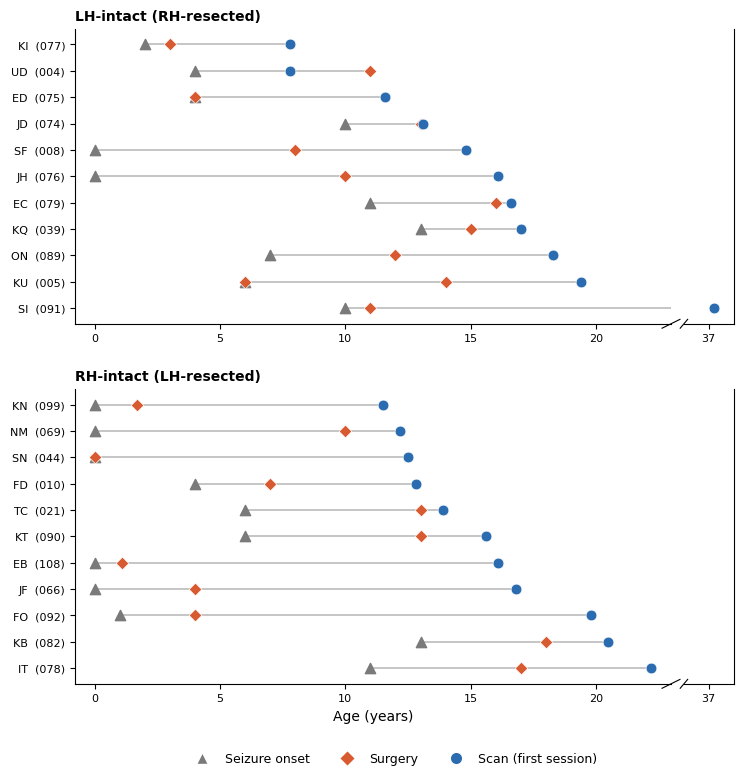

In [4]:
#!/usr/bin/env python
"""
Patient clinical timeline figure (Liu-style, on a real age axis).
Two panels: LH-intact (RH-resected) and RH-intact (LH-resected).
Markers: seizure onset (triangle), surgery (diamond), scan (circle = first session).
Broken x-axis to accommodate sub-091 (scan age 37.3).
Edit the LH/RH lists to adjust values; nothing is auto-derived.
"""
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---- data: (label, seizure_y, surgery_y, scan_y) ----
# None = not available / not plotted. scan_y = first-session scan age.
LH = [  # LH-intact, sorted by scan age
    ("KI  (077)",  2.0,  3.0,  7.8),
    ("UD  (004)",  4.0, 11.0,  7.8),
    ("ED  (075)",  4.0,  4.0, 11.6),
    ("JD  (074)", 10.0, 13.0, 13.1),
    ("SF  (008)",  0.0,  8.0, 14.8),
    ("JH  (076)",  0.0, 10.0, 16.1),
    ("EC  (079)", 11.0, 16.0, 16.6),
    ("KQ  (039)", 13.0, 15.0, 17.0),
    ("ON  (089)",  7.0, 12.0, 18.3),
    ("KU  (005)",  6.0, (6.0, 14.0), 19.4),
    ("SI  (091)", 10.0, 11.0, 37.3),
]
RH = [  # RH-intact, sorted by scan age
    ("KN  (099)",  0.0,  1.7, 11.5),
    ("NM  (069)",  0.0, 10.0, 12.2),
    ("SN  (044)",  0.0,  0.0, 12.5),   # surgery = 1 day -> plotted at 0, labeled "1d"
    ("FD  (010)",  4.0,  7.0, 12.8),
    ("TC  (021)",  6.0, 13.0, 13.9),
    ("KT  (090)",  6.0, 13.0, 15.6),
    ("EB  (108)",  0.0,  1.1, 16.1),
    ("JF  (066)",  0.0,  4.0, 16.8),
    ("FO  (092)",  1.0,  4.0, 19.8),
    ("KB  (082)", 13.0, 18.0, 20.5),
    ("IT  (078)", 11.0, 17.0, 22.2),
]

C_SEIZ, C_SURG, C_SCAN = "#7A7A7A", "#D85A30", "#2B6CB0"
LINE = "#BBBBBB"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 38.5

def draw_panel(ax_main, ax_brk, rows, title):
    n = len(rows)
    for i, (lab, sz, su, sc) in enumerate(rows):
        y = n - 1 - i
        su_list = [] if su is None else (list(su) if isinstance(su, (tuple, list)) else [su])
        pts = [v for v in ([sz] + su_list + [sc]) if v is not None]
        ax_main.plot([min(pts), min(max(pts), MAIN_MAX)], [y, y],
                     color=LINE, lw=1.2, zorder=1)
        for ax in (ax_main, ax_brk):
            if sz is not None:
                ax.scatter(sz, y, marker="^", s=55, color=C_SEIZ, zorder=3)
            for sv in su_list:
                ax.scatter(sv, y, marker="D", s=42, color=C_SURG, zorder=3,
                           edgecolors="white", linewidths=0.5)
            ax.scatter(sc, y, marker="o", s=60, color=C_SCAN, zorder=3,
                       edgecolors="white", linewidths=0.5)
    ax_main.set_yticks(range(n))
    ax_main.set_yticklabels([r[0] for r in reversed(rows)], fontsize=8)
    ax_main.set_ylim(-0.6, n - 0.4)
    ax_main.set_xlim(-0.8, MAIN_MAX)
    ax_brk.set_xlim(BRK_LO, BRK_HI)
    ax_brk.set_yticks([])
    ax_brk.set_ylim(-0.6, n - 0.4)
    ax_main.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax_main.spines["right"].set_visible(False)
    ax_brk.spines["left"].set_visible(False)
    ax_brk.set_xticks([37])
    for ax in (ax_main, ax_brk):
        ax.spines["top"].set_visible(False)
        ax.tick_params(labelsize=8)
    d = .015
    kw = dict(transform=ax_main.transAxes, color="k", clip_on=False, lw=0.8)
    ax_main.plot((1 - d, 1 + d), (-d, d), **kw)
    kw.update(transform=ax_brk.transAxes)
    ax_brk.plot((-d * 5, d * 5), (-d, d), **kw)

fig = plt.figure(figsize=(8.5, 8.4))
gs = gridspec.GridSpec(2, 2, width_ratios=[12, 1], height_ratios=[1, 1],
                       wspace=0.04, hspace=0.22)
axL, axLb = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
axR, axRb = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
draw_panel(axL, axLb, LH, "LH-intact (RH-resected)")
draw_panel(axR, axRb, RH, "RH-intact (LH-resected)")
axR.set_xlabel("Age (years)", fontsize=10)

handles = [
    plt.Line2D([], [], marker="^", color="w", markerfacecolor=C_SEIZ, ms=9, label="Seizure onset"),
    plt.Line2D([], [], marker="D", color="w", markerfacecolor=C_SURG, ms=8, label="Surgery"),
    plt.Line2D([], [], marker="o", color="w", markerfacecolor=C_SCAN, ms=9, label="Scan (first session)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.subplots_adjust(bottom=0.10)

'''
fig.savefig("/mnt/user-data/outputs/patient_timeline.png", dpi=200, bbox_inches="tight")
fig.savefig("/mnt/user-data/outputs/patient_timeline.pdf", bbox_inches="tight")
print("saved")
'''

In [1]:
import pandas as pd

# Rows ordered to match the timeline figure: LH-intact then RH-intact, each by first-scan age.
# '—' = not recorded / fill in.
_rows = [
    # Sub-ID,    Code, Sex, Surgery type,                                              Intact, Sessions
    ("sub-077", "KI", "F", "—",                                                        "Left",  1),
    ("sub-004", "UD", "M", "Right occipital & posterior temporal lobectomy",           "Left",  5),
    ("sub-075", "ED", "F", "—",                                                        "Left",  1),
    ("sub-074", "JD", "F", "—",                                                        "Left",  1),
    ("sub-008", "SF", "F", "—",                                                        "Left",  2),
    ("sub-076", "JH", "M", "—",                                                        "Left",  1),
    ("sub-079", "EC", "M", "—",                                                        "Left",  2),
    ("sub-039", "KQ", "F", "—",                                                        "Left",  1),
    ("sub-089", "ON", "M", "—",                                                        "Left",  1),
    ("sub-005", "KU", "M", "Partial resection of right parieto-occipital tumor (×2)",  "Left",  1),
    ("sub-091", "SI", "M", "Right anatomical hemispherectomy",                         "Left",  1),
    ("sub-099", "KN", "M", "Left anatomical hemispherectomy",                          "Right", 1),
    ("sub-069", "NM", "F", "—",                                                        "Right", 1),
    ("sub-044", "SN", "M", "Evacuation of left temporal hematoma",                     "Right", 1),
    ("sub-010", "FD", "M", "—",                                                        "Right", 2),
    ("sub-021", "TC", "F", "Left posterior parietal & occipital lobectomy",            "Right", 2),
    ("sub-090", "KT", "F", "Left functional hemispherectomy",                          "Right", 1),
    ("sub-108", "EB", "F", "Left anatomical hemispherectomy",                          "Right", 2),
    ("sub-066", "JF", "M", "—",                                                        "Right", 1),
    ("sub-092", "FO", "F", "Left anatomical hemispherectomy",                          "Right", 1),
    ("sub-082", "KB", "M", "SEEG-guided resection of left T1 & Heschl gyrus",          "Right", 1),
    ("sub-078", "IT", "F", "—",                                                        "Right", 1),
]

patient_table = pd.DataFrame(
    _rows, columns=["Sub-ID", "Code", "Sex", "Surgery type", "Intact", "Sessions"]
)

with pd.option_context("display.max_colwidth", None):
    display(patient_table)

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Sub-ID,Code,Sex,Surgery type,Intact,Sessions
0,sub-077,KI,F,—,Left,1
1,sub-004,UD,M,Right occipital & posterior temporal lobectomy,Left,5
2,sub-075,ED,F,—,Left,1
3,sub-074,JD,F,—,Left,1
4,sub-008,SF,F,—,Left,2
5,sub-076,JH,M,—,Left,1
6,sub-079,EC,M,—,Left,2
7,sub-039,KQ,F,—,Left,1
8,sub-089,ON,M,—,Left,1
9,sub-005,KU,M,Partial resection of right parieto-occipital tumor (×2),Left,1
